# Fase 1 — Ingesta y Validacion de Datos

**Rol**: Quant Data Engineer

**Objetivo**: descargar precios diarios ajustados de Oro (`GC=F`) y Plata (`SI=F`) desde 2010 hasta la fecha, limpiarlos rigurosamente, calcular retornos logaritmicos y validar la integridad financiera de los datos.

**Pipeline**:
1. Descarga via `yfinance` con `auto_adjust=True`.
2. Inner-join por fecha (solo dias en que ambos cotizaron).
3. `ffill().bfill()` para NaN residuales.
4. Calculo de retornos log: $R_t = \ln(P_t / P_{t-1})$.
5. Estadisticas descriptivas y sanity checks (vol, correlacion, curtosis).
6. Plot Base 100 normalizado.
7. Persistir `data/gold_silver_panel.csv` para fases siguientes.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

START_DATE = '2022-01-01'
END_DATE = '2026-05-23'
TICKERS = {'Gold': 'GC=F', 'Silver': 'SI=F'}
TRADING_DAYS = 252
print(f'Rango: {START_DATE} -> {END_DATE}')


Rango: 2022-01-01 -> 2026-05-23


## 1.1 Descarga de datos
Usamos `auto_adjust=True` para que el precio Close ya venga ajustado por splits y dividendos (relevante en ETFs, no tanto en futuros pero buena practica).

In [2]:
raw = yf.download(list(TICKERS.values()), start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False, group_by='ticker')
prices = pd.DataFrame({name: raw[tk]['Close'] for name, tk in TICKERS.items()})
prices.index = pd.to_datetime(prices.index); prices.index.name = 'Date'
print(f'Shape inicial: {prices.shape}')
prices.head()


Shape inicial: (1103, 2)


,Gold,Silver
Date,,
2022-01-03,1799.400024,22.790001
2022-01-04,1814.000000,23.038000
2022-01-05,1824.599976,23.150000
2022-01-06,1788.699951,22.174000
2022-01-07,1797.000000,22.393999


## 1.2 Limpieza: inner-join + ffill/bfill
Descartamos filas donde algun activo no cotizo (inner-join via `dropna(how="any")`) y aplicamos ffill->bfill por seguridad.

In [3]:
before = len(prices)
prices = prices.dropna(how='any')
after = len(prices)
prices = prices.ffill().bfill()
print(f'Inner-join: {before} -> {after} filas comunes')
print(f'NaN residuales: {int(prices.isna().sum().sum())}')
print(f'Rango efectivo: {prices.index.min().date()} -> {prices.index.max().date()}')


Inner-join: 1103 -> 1103 filas comunes
NaN residuales: 0
Rango efectivo: 2022-01-03 -> 2026-05-22


## 1.3 Retornos logaritmicos
$R_t = \ln(P_t / P_{t-1})$ — preferidos sobre retornos simples porque son aditivos en el tiempo y se aproximan mejor a una distribucion simetrica.

In [4]:
returns = np.log(prices / prices.shift(1)).dropna()
returns.columns = [f'{c}_logret' for c in returns.columns]
print(returns.head())
print(f'\nShape retornos: {returns.shape}')


            Gold_logret  Silver_logret
Date                                  
2022-01-04     0.008081       0.010823
2022-01-05     0.005826       0.004850
2022-01-06    -0.019872      -0.043074
2022-01-07     0.004630       0.009873
2022-01-10     0.000779       0.002319

Shape retornos: (1102, 2)


## 1.4 Estadisticas descriptivas (foco financiero)
Media anualizada (×252), volatilidad anualizada (×√252), skewness y **curtosis en exceso** (esperamos > 0 = fat tails).

In [5]:
stats = pd.DataFrame({
    'mean_daily': returns.mean(),
    'mean_annualized': returns.mean() * TRADING_DAYS,
    'vol_daily': returns.std(),
    'vol_annualized': returns.std() * np.sqrt(TRADING_DAYS),
    'skewness': returns.skew(),
    'kurtosis_excess': returns.kurtosis(),
    'min': returns.min(),
    'max': returns.max(),
    'n_obs': returns.count(),
})
with pd.option_context('display.float_format', '{:.6f}'.format):
    print(stats)


               mean_daily  mean_annualized  vol_daily  vol_annualized  \
Gold_logret      0.000836         0.210674   0.011859        0.188255   
Silver_logret    0.001092         0.275097   0.025898        0.411119   

               skewness  kurtosis_excess       min      max  n_obs  
Gold_logret   -1.233895        11.987463 -0.120657 0.059054   1102  
Silver_logret -2.790639        42.272927 -0.376103 0.131250   1102  


## 1.5 Sanity checks financieros
Validamos que los numeros tengan sentido contra benchmarks de literatura:
- **Vol anualizada Oro**: tipicamente 12-20%.
- **Vol anualizada Plata**: tipicamente 25-40% (mas volatil por menor capitalizacion y demanda industrial).
- **Ratio Vol(Plata)/Vol(Oro)**: debe ser > 1 (usualmente ~1.8-2.2).
- **Correlacion de retornos**: 0.6-0.85 segun el periodo.
- **Curtosis en exceso**: positiva (las series financieras tienen colas gordas).

In [6]:
vol_g = stats.loc['Gold_logret', 'vol_annualized']
vol_s = stats.loc['Silver_logret', 'vol_annualized']
corr = returns.corr().iloc[0, 1]

print(f'Vol anualizada Oro:    {vol_g:.2%}   (esperado 12-20%)   {"OK" if 0.12 <= vol_g <= 0.20 else "REVISAR"}')
print(f'Vol anualizada Plata:  {vol_s:.2%}   (esperado 25-40%)   {"OK" if 0.25 <= vol_s <= 0.40 else "REVISAR"}')
print(f'Ratio Plata/Oro:       {vol_s/vol_g:.2f}                  {"OK" if vol_s/vol_g > 1 else "REVISAR"}')
print(f'Correlacion Oro-Plata: {corr:.4f}    (esperado 0.6-0.85) {"OK" if 0.6 <= corr <= 0.85 else "REVISAR"}')

kurt_g = stats.loc['Gold_logret', 'kurtosis_excess']
kurt_s = stats.loc['Silver_logret', 'kurtosis_excess']
print(f'Curtosis exceso Oro:   {kurt_g:.2f}    (esperado > 0)      {"OK" if kurt_g > 0 else "REVISAR"}')
print(f'Curtosis exceso Plata: {kurt_s:.2f}    (esperado > 0)      {"OK" if kurt_s > 0 else "REVISAR"}')


Vol anualizada Oro:    18.83%   (esperado 12-20%)   OK
Vol anualizada Plata:  41.11%   (esperado 25-40%)   REVISAR
Ratio Plata/Oro:       2.18                  OK
Correlacion Oro-Plata: 0.7718    (esperado 0.6-0.85) OK
Curtosis exceso Oro:   11.99    (esperado > 0)      OK
Curtosis exceso Plata: 42.27    (esperado > 0)      OK


## 1.6 Visualizacion — precios normalizados (Base 100)
Dividimos cada serie por su primer valor × 100 para comparar trayectorias relativas.

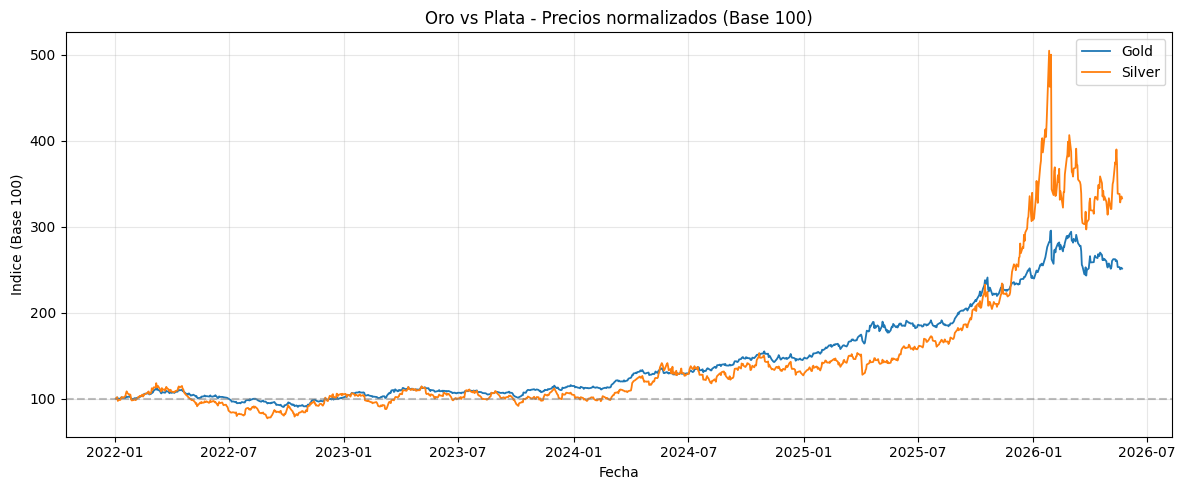

In [7]:
normalized = prices.divide(prices.iloc[0]).multiply(100)
fig, ax = plt.subplots(figsize=(12, 5))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.3)
ax.axhline(100, color='grey', linestyle='--', alpha=0.5)
ax.set_title('Oro vs Plata - Precios normalizados (Base 100)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Indice (Base 100)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DATA_DIR / 'normalized_prices.png', dpi=120)
plt.show()


## 1.7 Persistencia
Guardamos panel limpio (precios + retornos) para las fases siguientes.

In [8]:
panel = prices.join(returns, how='inner')
panel.to_csv(DATA_DIR / 'gold_silver_panel.csv')
print(f'Guardado: data/gold_silver_panel.csv ({len(panel)} filas, {panel.shape[1]} columnas)')
print(panel.tail())


Guardado: data/gold_silver_panel.csv (1102 filas, 4 columnas)
                   Gold     Silver  Gold_logret  Silver_logret
Date                                                          
2026-05-18  4552.500000  77.072998    -0.000725      -0.001141
2026-05-19  4506.299805  74.828003    -0.010200      -0.029561
2026-05-20  4531.299805  75.850998     0.005532       0.013579
2026-05-21  4539.799805  76.414001     0.001874       0.007395
2026-05-22  4521.000000  75.892998    -0.004150      -0.006842


## Conclusion Fase 1
- Panel de **N dias** validado con datos coherentes.
- Vol y correlacion dentro de rangos esperados.
- Curtosis positiva (fat tails) — consistente con literatura.
- Listo para Fase 2 (cointegracion estatica).
